# Notebook 5 — EEGNet: A Compact CNN for EEG Decoding

---

## Section 0 — What we're building on

### Prior concepts you already have

From the **CSP + LDA/SVM notebook**, you know:
- CSP finds spatial filters $\mathbf{w}$ that maximize the variance ratio between two classes: $\max \frac{\mathbf{w}^T \Sigma_1 \mathbf{w}}{\mathbf{w}^T \Sigma_2 \mathbf{w}}$
- The solution is a **generalized eigenvalue decomposition** — a closed-form optimization with no learning rate, no epochs, no gradient descent.
- CSP features are **log-variance** of spatially filtered signals: $f_j = \log(\text{var}(\mathbf{w}_j^T \mathbf{X}))$
- On Dataset 2a, CSP + LDA/SVM achieves a certain accuracy and kappa across 9 subjects. These are your **baseline numbers** that EEGNet must beat (or at least match) to justify the added complexity.

From your **PyTorch experience**, you know:
- `nn.Module`, `forward()`, `Dataset`, `DataLoader`
- Training loop: zero grad → forward → loss → backward → optimizer step
- Cross-entropy loss, softmax, dropout, batch norm
- Standard 2D convolution (`nn.Conv2d`)

From **signal processing and EEG exploration**, you know:
- ERD: motor imagery causes band power suppression over contralateral motor cortex
- The discriminative signal lives in specific frequency bands (mu: 8–13 Hz, beta: 13–30 Hz) at specific channels (C3, C4, Cz)

### What this notebook adds

EEGNet replaces the entire CSP + classifier pipeline with a single end-to-end neural network. The key insight is that **each stage of CSP + LDA maps onto a specific layer type** in EEGNet:

| CSP + LDA stage | EEGNet layer | What it does |
|---|---|---|
| Band-pass filter | Temporal Conv (`Conv2d` across time) | Learns frequency-selective filters |
| CSP spatial filter | Depthwise Conv (`Conv2d` across channels) | Learns spatial filters per frequency |
| Feature extraction + classifier | Separable Conv + Dense | Learns temporal patterns + classification |

The three new concepts you'll learn:

1. **Depthwise convolution** — a constrained convolution where each input channel gets its *own* filter. This is how EEGNet learns spatial filters (like CSP) without mixing channels prematurely.
2. **Separable convolution** — depthwise + pointwise (1×1 conv). Dramatically reduces parameters compared to standard conv.
3. **Why this architecture works for EEG** — the design isn't arbitrary. Each layer exploits known EEG structure.

### Clinical / practical context

> **Why EEGNet?** EEGNet (Lawhern et al., 2018) is the most widely cited compact CNN for BCI. Every serious BCI paper reports EEGNet numbers as a deep learning baseline, just as CSP+LDA is the traditional baseline. It was designed to work across *multiple* BCI paradigms (motor imagery, P300, SSVEP) with minimal architecture changes — making it the closest thing BCI has to a general-purpose decoder.
>
> For deployed BCI products, EEGNet's compactness matters: it has ~2,000 parameters (vs. hundreds of thousands for deeper CNNs), which means it can run on edge devices and re-calibrate quickly for new users.

---

## Part 1 — Setup and Data Loading

In [49]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
import os
import sys

# Import preprocessing pipeline
sys.path.insert(0, '../4.data preprocessing')
from run_pipeline import run_pipeline

DATA_DIR = '../mne_data/bci_iv_2a'

In [50]:
# Device configuration
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Using device: {DEVICE}")

Using device: mps


In [51]:
# ⚠️  COMPUTE NOTE
# Training EEGNet on all 9 subjects is manageable on MPS (~20 min total).
# If using CPU only, expect ~45–60 min total.
# For faster iteration, develop on a single subject first (Part 1–7),
# then run the full 9-subject sweep in Part 8.

### Load data for one subject (development)

We'll build and debug everything on Subject A01 first, then sweep all 9 subjects at the end.

Recall: `run_pipeline()` returns a **dict** with keys `'X_train'`, `'X_test'`, `'y_train'`, `'y_test'`.
- `X_train` shape: `(n_train_windows, 22, 250)` — z-scored, band-passed, windowed EEG
- `y_train` shape: `(n_train_windows,)` — integer labels 0–3
- Same for test

In [52]:
data = run_pipeline('A01', DATA_DIR)
X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}, classes: {np.unique(y_train)}")
print(f"y_test:  {y_test.shape},  classes: {np.unique(y_test)}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
X_train: (690, 22, 250)
X_test:  (174, 22, 250)
y_train: (690,), classes: [0 1 2 3]
y_test:  (174,),  classes: [0 1 2 3]


---

## Part 2 — PyTorch Dataset

### What and why

We need to wrap our NumPy arrays in a `torch.utils.data.Dataset` so we can use `DataLoader` for batching, shuffling, and efficient iteration.

**EEGNet input format:** `(B, 1, C, T)`
- `B` = batch size
- `1` = a singleton "kernel" dimension (EEGNet treats this like a single input image channel)
- `C` = 22 EEG channels
- `T` = 250 time samples (1 second at 250 Hz)

The pipeline outputs `(n_windows, 22, 250)`, which is `(N, C, T)`. We need to add the singleton dimension with `.unsqueeze(1)` to get `(N, 1, C, T)`.

> **Why the extra dimension?** EEGNet's first convolution (`Conv2d`) expects a 4D input. The singleton dimension represents "1 input feature map" — analogous to a grayscale image having 1 color channel. After the first temporal convolution produces `F1` feature maps, this dimension becomes `F1`.

### Task

Implement `EEGDataset.__init__` and `__getitem__`.

```
Args:
    X: np.ndarray, shape (N, C, T) — preprocessed EEG windows
    y: np.ndarray, shape (N,) — integer class labels

__getitem__ returns:
    x: torch.FloatTensor, shape (1, C, T) — single trial with singleton dim added
    label: torch.LongTensor, scalar — class label
```

Pseudocode:
1. In `__init__`: convert X to float32 tensor, y to long tensor. Store both.
2. In `__getitem__`: index into stored tensors, add singleton dimension to x with `.unsqueeze(0)`.
3. `__len__`: return number of samples.

In [53]:
class EEGDataset(Dataset):
    """
    Wraps EEG data for PyTorch DataLoader.
    
    Args:
        X: np.ndarray, shape (N, C, T) — preprocessed EEG windows
        y: np.ndarray, shape (N,) — integer class labels 0–3
    
    __getitem__ returns:
        x: FloatTensor, shape (1, C, T) — one trial with singleton dim
        label: LongTensor, scalar
    """
    def __init__(self, X, y):
        # YOUR CODE HERE
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)
    
    def __len__(self):
        # YOUR CODE HERE
        return len(self.X)
    
    def __getitem__(self, idx):
        # YOUR CODE HERE
        return self.X[idx].unsqueeze(0),self.y[idx]

In [54]:
# Sanity check — Dataset
_ds = EEGDataset(X_train, y_train)
_x, _label = _ds[0]
assert len(_ds) == len(X_train), f"Length mismatch: {len(_ds)} vs {len(X_train)}"
assert _x.shape == (1, 22, 250), f"Expected (1, 22, 250), got {_x.shape}"
assert _x.dtype == torch.float32, f"Expected float32, got {_x.dtype}"
assert _label.dtype == torch.long, f"Expected long, got {_label.dtype}"
assert _label.dim() == 0, f"Label should be scalar, got shape {_label.shape}"
print(f"✓ Dataset: {len(_ds)} samples, x shape {_x.shape}, label dtype {_label.dtype}")

✓ Dataset: 690 samples, x shape torch.Size([1, 22, 250]), label dtype torch.int64


### Create DataLoaders

In [55]:
BATCH_SIZE = 64

train_ds = EEGDataset(X_train, y_train)
test_ds  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Verify one batch
_xb, _yb = next(iter(train_loader))
print(f"Batch x: {_xb.shape}, y: {_yb.shape}")
# Expected: x = (64, 1, 22, 250), y = (64,)

Batch x: torch.Size([64, 1, 22, 250]), y: torch.Size([64])


---

## Part 3 — Depthwise Convolution: The Key Concept

Before building EEGNet, you need to understand the one convolution variant that makes the whole architecture work: **depthwise convolution**.

### Standard Conv2d vs Depthwise Conv2d

**Standard convolution** with $C_{in}$ input channels and $C_{out}$ output channels uses a weight tensor of shape:
$$W \in \mathbb{R}^{C_{out} \times C_{in} \times k_H \times k_W}$$

Every output channel mixes **all** input channels — the filter looks at every channel simultaneously.

**Depthwise convolution** constrains each filter to operate on exactly **one** input channel. If you have $C_{in}$ input channels, you get $C_{in}$ independent filters. The weight tensor has shape:
$$W \in \mathbb{R}^{C_{in} \times 1 \times k_H \times k_W}$$

Note the `1` in the second dimension — this is the depthwise constraint. Each filter only sees one channel.

In PyTorch, depthwise convolution is just a regular `Conv2d` with the `groups` parameter set to the number of input channels:
```python
nn.Conv2d(in_channels=C_in, out_channels=C_in, kernel_size=k,
          groups=C_in)  # ← this makes it depthwise
```

When `groups=C_in`, PyTorch splits both input and output channels into `C_in` groups of 1, and each group gets its own filter.

**But EEGNet does something slightly different.** It uses `groups=F1` (the number of temporal filters), not `groups=C_in`. This is because after the temporal convolution, the data has `F1` feature maps, and the depthwise conv learns `D` spatial filters *per temporal filter*. So:
```python
nn.Conv2d(in_channels=F1, out_channels=F1 * D, kernel_size=(C, 1),
          groups=F1)  # D spatial filters per temporal filter
```

### Why depthwise conv = spatial filtering

Think about what a kernel of size `(C, 1)` does — it spans all 22 channels but only 1 time point. This is a **spatial filter**: it computes a weighted sum across channels at each time point, exactly like CSP.

The difference: CSP computes spatial filters from class covariances (closed-form). EEGNet *learns* them from data (gradient descent). The depthwise constraint ensures each temporal feature gets its own set of spatial filters, preventing the network from learning redundant spatial patterns.

### Parameter count comparison

For the spatial filtering step with $F_1 = 8$ temporal features, $D = 2$ spatial filters per feature, and $C = 22$ channels:

| Method | Parameters |
|---|---|
| Standard Conv2d(8, 16, (22,1)) | $8 \times 16 \times 22 \times 1 = 2{,}816$ |
| Depthwise Conv2d(8, 16, (22,1), groups=8) | $8 \times 2 \times 22 \times 1 = 352$ |

Depthwise uses **8× fewer parameters** — critical when you only have ~288 training trials per subject.

### Separable convolution = depthwise + pointwise

A **separable convolution** factors a standard convolution into two steps:
1. **Depthwise conv**: each channel filtered independently (spatial/temporal patterns)
2. **Pointwise conv (1×1)**: a `Conv2d` with kernel size `(1, 1)` that mixes information *across* channels

This factorization captures the same expressiveness as a standard conv with far fewer parameters. EEGNet's Block 2 uses this for temporal filtering.

### Task — Verify your understanding

Before implementing EEGNet, create a small depthwise conv and verify its weight shape.

In [56]:
# Sanity check — Depthwise conv weight shape
# Create a depthwise conv: 8 input channels, 16 output channels (D=2 per input),
# kernel (22, 1), groups=8
_dw_conv = nn.Conv2d(8, 16, (22, 1), groups=8, bias=False)
print(f"Depthwise conv weight shape: {_dw_conv.weight.shape}")
# Expected: (16, 1, 22, 1)
# The '1' in dim=1 is the depthwise constraint: each filter sees only 1 input channel
assert _dw_conv.weight.shape == (16, 1, 22, 1), f"Unexpected shape: {_dw_conv.weight.shape}"

# Compare with standard conv
_std_conv = nn.Conv2d(8, 16, (22, 1), bias=False)
print(f"Standard conv weight shape:  {_std_conv.weight.shape}")
# Expected: (16, 8, 22, 1)

_dw_params = sum(p.numel() for p in _dw_conv.parameters())
_std_params = sum(p.numel() for p in _std_conv.parameters())
print(f"\nDepthwise params: {_dw_params}")
print(f"Standard params:  {_std_params}")
print(f"Ratio: {_std_params / _dw_params:.1f}x more parameters in standard conv")
print("✓ Depthwise conv weight shape verified")

Depthwise conv weight shape: torch.Size([16, 1, 22, 1])
Standard conv weight shape:  torch.Size([16, 8, 22, 1])

Depthwise params: 352
Standard params:  2816
Ratio: 8.0x more parameters in standard conv
✓ Depthwise conv weight shape verified


---

## Part 4 — EEGNet Architecture

### Full architecture overview

EEGNet has two convolutional blocks followed by a dense classifier:

```
Input: (B, 1, C=22, T=250)
        │
  ┌─────▼──────────────────────────────────────────┐
  │ Block 1 — Temporal + Spatial filtering          │
  │                                                 │
  │  Conv2d(1, F1, (1, kern_len))     → (B, F1, C, T)          temporal       │
  │  BatchNorm2d(F1)                                            │
  │  DepthwiseConv2d(F1, F1*D, (C, 1), groups=F1) → (B, F1*D, 1, T)  spatial │
  │  BatchNorm2d(F1*D)                                          │
  │  ELU                                                        │
  │  AvgPool2d(1, pool1)              → (B, F1*D, 1, T//pool1)  │
  │  Dropout(p)                                                 │
  └─────┬──────────────────────────────────────────┘
        │
  ┌─────▼──────────────────────────────────────────┐
  │ Block 2 — Separable convolution                 │
  │                                                 │
  │  SeparableConv2d:                                           │
  │    DepthwiseConv2d(F1*D, F1*D, (1, sep_kern), groups=F1*D)  │
  │    PointwiseConv2d(F1*D, F2, (1, 1))           → (B, F2, 1, T//pool1)    │
  │  BatchNorm2d(F2)                                            │
  │  ELU                                                        │
  │  AvgPool2d(1, pool2)              → (B, F2, 1, T//(pool1*pool2))          │
  │  Dropout(p)                                                 │
  └─────┬──────────────────────────────────────────┘
        │
  ┌─────▼──────────────────────────────────────────┐
  │ Classifier                                      │
  │  Flatten       → (B, F2 * T//(pool1*pool2))                │
  │  Linear        → (B, n_classes)                             │
  └────────────────────────────────────────────────┘
```

### Hyperparameters (default for Dataset 2a)

| Parameter | Value | Meaning |
|---|---|---|
| `n_channels` (C) | 22 | Number of EEG channels |
| `n_timepoints` (T) | 250 | Samples per window (1s at 250 Hz) |
| `n_classes` | 4 | Motor imagery classes |
| `F1` | 8 | Number of temporal filters |
| `D` | 2 | Depth multiplier (spatial filters per temporal filter) |
| `F2` | `F1 * D` = 16 | Number of pointwise filters |
| `kern_len` | 125 | Temporal kernel length = `fs // 2` = 250 // 2 |
| `sep_kern` | 16 | Separable conv temporal kernel |
| `pool1` | 4 | First average pooling factor |
| `pool2` | 8 | Second average pooling factor |
| `dropout` | 0.5 | Dropout probability |

> **Why `kern_len = fs // 2 = 125`?** A temporal kernel of 125 samples at 250 Hz spans 0.5 seconds. By the Nyquist-adjacent reasoning: a kernel of length $L$ samples can capture frequencies as low as $f_{\min} \approx \frac{f_s}{L} = \frac{250}{125} = 2$ Hz. This means the temporal conv can learn filters that capture delta (1–4 Hz) through gamma (>30 Hz) — the full EEG-relevant range. Setting `kern_len = fs // 2` is the EEGNet paper's recommended default.

### Dimension walkthrough

Let's trace a batch through the network step by step (B=64 for concreteness):

| Step | Operation | Output Shape | What happened |
|---|---|---|---|
| Input | — | (64, 1, 22, 250) | Raw EEG with singleton dim |
| Temporal conv | Conv2d(1→8, kernel=(1,125), pad=(0,62)) | (64, 8, 22, 250) | 8 frequency-selective filters; `same` padding preserves T |
| BatchNorm | BN(8) | (64, 8, 22, 250) | Normalize each temporal filter |
| Depthwise conv | Conv2d(8→16, kernel=(22,1), groups=8) | (64, 16, 1, 250) | 2 spatial filters per temporal filter; C collapses to 1 |
| BatchNorm | BN(16) | (64, 16, 1, 250) | Normalize each spatial filter output |
| ELU | — | (64, 16, 1, 250) | Non-linearity |
| AvgPool | pool(1, 4) | (64, 16, 1, 62) | Downsample time by 4× |
| Dropout | — | (64, 16, 1, 62) | Regularization |
| Sep. depthwise | Conv2d(16→16, kernel=(1,16), groups=16, pad=(0,8)) | (64, 16, 1, 62) | Temporal patterns per channel |
| Sep. pointwise | Conv2d(16→16, kernel=(1,1)) | (64, 16, 1, 62) | Mix across channels |
| BatchNorm | BN(16) | (64, 16, 1, 62) | Normalize |
| ELU | — | (64, 16, 1, 62) | Non-linearity |
| AvgPool | pool(1, 8) | (64, 16, 1, 7) | Downsample time by 8× |
| Dropout | — | (64, 16, 1, 7) | Regularization |
| Flatten | — | (64, 112) | 16 × 1 × 7 = 112 |
| Linear | 112 → 4 | (64, 4) | Class logits |

Note: The exact value of the last time dimension (7 above) depends on rounding from pooling. The implementation computes this dynamically.

> **Why ELU instead of ReLU?** ELU (Exponential Linear Unit) has non-zero gradients for negative inputs: $\text{ELU}(x) = x$ if $x > 0$, else $\alpha(e^x - 1)$. For EEG, signal values are centered around zero (z-scored), so ReLU would kill ~half the signal. ELU preserves negative activations while still being non-linear.

### Padding strategy for `same` output

For a 1D convolution with kernel size $k$ and stride 1, `same` padding requires padding of $\lfloor k/2 \rfloor$ on each side. Since our temporal convolutions operate along the last dimension (width), we use:
```python
padding=(0, kern_len // 2)  # no padding in height (channel dim), same padding in width (time)
```

### Task — Implement EEGNet

Implement the `EEGNet` class. Define all layers in `__init__` and wire them in `forward`.

```
Args (to __init__):
    n_channels: int — number of EEG channels (22)
    n_timepoints: int — samples per window (250)
    n_classes: int — number of output classes (4)
    F1: int — number of temporal filters (8)
    D: int — depth multiplier (2)
    F2: int — number of pointwise filters, default F1*D (16)
    kern_len: int — temporal kernel length (125)
    sep_kern: int — separable conv kernel length (16)
    pool1: int — first pooling factor (4)
    pool2: int — second pooling factor (8)
    dropout: float — dropout rate (0.5)

forward(x):
    x: shape (B, 1, C, T)
    returns: shape (B, n_classes) — raw logits (no softmax)
```

**Implementation hints:**
- Use `nn.Conv2d(..., bias=False)` before every `BatchNorm2d` (BN absorbs the bias).
- For the depthwise conv in Block 1: `groups=F1`, `in_channels=F1`, `out_channels=F1*D`.
- For the separable depthwise conv in Block 2: `groups=F2`, `in_channels=F2`, `out_channels=F2`, with `padding=(0, sep_kern//2)` for `same` output.
- For the separable pointwise conv: `Conv2d(F2, F2, (1, 1))`.
- To compute the flattened size for the Linear layer, either:
  - Calculate: `F2 * (n_timepoints // (pool1 * pool2))`, or
  - Pass a dummy tensor through the conv layers in `__init__` and read the shape.

In [57]:
class EEGNet(nn.Module):
    """
    EEGNet: A compact convolutional neural network for EEG-based BCIs.
    
    Architecture:
        Block 1: Temporal Conv → BN → Depthwise Conv → BN → ELU → AvgPool → Dropout
        Block 2: Separable Conv (Depthwise + Pointwise) → BN → ELU → AvgPool → Dropout
        Classifier: Flatten → Linear
    
    Args:
        n_channels: int, number of EEG channels (22)
        n_timepoints: int, time samples per window (250)
        n_classes: int, number of output classes (4)
        F1: int, temporal filters (8)
        D: int, depth multiplier for spatial filters (2)
        F2: int, pointwise filters (default F1*D=16)
        kern_len: int, temporal kernel length (125)
        sep_kern: int, separable conv kernel (16)
        pool1: int, first pooling factor (4)
        pool2: int, second pooling factor (8)
        dropout: float, dropout rate (0.5)
    
    forward(x):
        x: (B, 1, C, T)
        returns: (B, n_classes) — logits
    """
    def __init__(self, n_channels=22, n_timepoints=250, n_classes=4,
                 F1=8, D=2, F2=None, kern_len=125, sep_kern=16,
                 pool1=4, pool2=8, dropout=0.5):
        super().__init__()
        if F2 is None:
            F2 = F1 * D
        
        # Store config for later use
        self.F1 = F1
        self.D = D
        self.F2 = F2
        
        # ============================================================
        # Block 1 — Temporal + Spatial filtering
        # YOUR CODE HERE: define the layers for Block 1
        #   self.temporal_conv  = ...
        #   self.bn1            = ...
        #   self.depthwise_conv = ...
        #   self.bn2            = ...
        #   self.pool1          = ...
        #   self.drop1          = ...
        # ============================================================
        self.block1 = nn.Sequential(
            nn.Conv2d(1,F1,kernel_size=(1,kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1,F1*D,(n_channels,1),groups = F1,bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1,pool1)),
            nn.Dropout2d(dropout)
        )
        
        # ============================================================
        # Block 2 — Separable convolution
        # YOUR CODE HERE: define the layers for Block 2
        #   self.sep_depthwise = ...
        #   self.sep_pointwise = ...
        #   self.bn3           = ...
        #   self.pool2         = ...
        #   self.drop2         = ...
        # ============================================================
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D,F1*D,kernel_size=(1,sep_kern),groups=F1*D, padding=(0,sep_kern//2), bias=False),
            nn.Conv2d(F1*D,F2,(1,1),bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1,pool2)),
            nn.Dropout2d(dropout)
        )
        
        # ============================================================
        # Classifier
        # YOUR CODE HERE: compute flattened size, define Linear layer
        #   self.classifier = ...
        # ============================================================
        _flat = F2 * (n_timepoints // (pool1 * pool2))

        self.classifier = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(_flat,n_classes)
        )
    
    def forward(self, x):
        """
        Args:
            x: (B, 1, C, T)
        Returns:
            logits: (B, n_classes)
        """
        # ============================================================
        # YOUR CODE HERE: wire the layers defined above
        # Block 1: temporal_conv → bn1 → depthwise_conv → bn2 → elu → pool1 → drop1
        # Block 2: sep_depthwise → sep_pointwise → bn3 → elu → pool2 → drop2
        # Classifier: flatten → classifier
        # ============================================================
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

In [58]:
# Sanity check — EEGNet architecture
_model = EEGNet(n_channels=22, n_timepoints=250, n_classes=4).to(DEVICE)

# Check output shape
with torch.no_grad():
    _x = torch.randn(4, 1, 22, 250).to(DEVICE)
    _out = _model(_x)
assert _out.shape == (4, 4), f"Expected (4, 4), got {_out.shape}"

# Check loss at random initialization: should be ≈ log(4) ≈ 1.386 for 4-class
_loss = F.cross_entropy(_out, torch.zeros(4, dtype=torch.long).to(DEVICE))
assert abs(_loss.item() - 1.386) < 0.3, f"Loss at init should be ≈log(4)=1.386, got {_loss.item():.3f}"

# Check depthwise conv weight shape
_dw_shape = _model.block1[2].weight.shape
assert _dw_shape[1] == 1, f"Depthwise conv dim=1 should be 1 (depthwise constraint), got {_dw_shape[1]}"
assert _dw_shape[2] == 22, f"Depthwise conv should span all 22 channels, got {_dw_shape[2]}"

# Check parameter count
_total_params = sum(p.numel() for p in _model.parameters())
print(f"Total parameters: {_total_params:,}")
print(f"Output shape: {_out.shape}")
print(f"Loss at init: {_loss.item():.3f} (expected ≈1.386)")
print(f"Depthwise weight shape: {_dw_shape} (dim=1 is 1 ✓)")
print(f"✓ EEGNet architecture verified")

Total parameters: 2,396
Output shape: torch.Size([4, 4])
Loss at init: 1.652 (expected ≈1.386)
Depthwise weight shape: torch.Size([16, 1, 22, 1]) (dim=1 is 1 ✓)
✓ EEGNet architecture verified


### Decision — EEGNet architecture choices

1. The temporal kernel is set to `fs // 2 = 125` samples. What frequency range can this kernel capture, and why is half the sampling rate a meaningful choice for EEG?

2. You used `n_components=4` for CSP (2 per class in OVR). EEGNet uses `F1=8` temporal filters and `D=2` spatial filters per temporal filter, giving 16 spatial features. What is the analogous design choice, and what would you lose by setting `F1=2`?

3. EEGNet was originally designed for 4-second epochs, but we use 1-second windows (250 samples). Does this change what frequency content the temporal filter can capture? What about the separable conv with kernel size 16?

*Write your answers here.*

---

## Part 5 — Weight Initialization (Optional but Recommended)

### Why initialization matters for small EEG datasets

With only ~288 training trials per subject (after windowing, somewhat more windows), the network can be sensitive to initialization. A common choice is **Xavier/Glorot uniform** for conv layers, which initializes weights so that the variance of activations stays roughly constant across layers.

This is already the PyTorch default for `Conv2d`. For the classifier (Linear), Xavier is also a reasonable choice. BatchNorm parameters don't need custom initialization (weight=1, bias=0 is the default and is correct).

If you want to match the original EEGNet paper, they use the Keras defaults, which are also Glorot uniform. PyTorch's defaults are close enough that you can skip custom initialization and it will work fine.

**No task here** — just be aware that if training is unstable, initialization is one thing to check.

---

## Part 6 — Training Loop

### What and why

You already know the standard PyTorch training loop. For EEGNet on small EEG datasets, a few things matter:

- **Adam optimizer** with a moderate learning rate (1e-3). EEGNet is small enough that Adam works well without a scheduler.
- **Cross-entropy loss** — same as any 4-class classification problem.
- **~300–500 epochs** — this sounds like a lot, but each epoch is tiny (~5–10 batches of 64 with ~400 training windows). The network sees relatively few gradient updates.
- **No early stopping** for now — we'll add that in the ablation. With heavy dropout (0.5), overfitting is controlled.

### Task — Implement train and evaluate functions

Implement two functions:

**`train_one_epoch`**
```
Args:
    model: nn.Module
    loader: DataLoader
    optimizer: torch.optim.Optimizer
    device: torch.device

Returns:
    avg_loss: float — mean cross-entropy loss over all batches
```

Pseudocode:
1. Set model to train mode.
2. For each batch: move to device → forward → compute loss → backward → step → accumulate loss.
3. Return average loss.

**`evaluate`**
```
Args:
    model: nn.Module
    loader: DataLoader
    device: torch.device

Returns:
    accuracy: float — fraction correct
    kappa: float — Cohen's kappa
    all_preds: np.ndarray — predicted labels
    all_labels: np.ndarray — true labels
```

Pseudocode:
1. Set model to eval mode, use `torch.no_grad()`.
2. For each batch: move to device → forward → argmax for predictions → collect.
3. Compute accuracy and Cohen's kappa from collected predictions and labels.

In [59]:
def train_one_epoch(model, loader, optimizer, device):
    """
    Train the model for one epoch.
    
    Args:
        model: nn.Module
        loader: DataLoader
        optimizer: torch.optim.Optimizer
        device: torch.device
    
    Returns:
        avg_loss: float — mean cross-entropy loss over all batches
    """
    # YOUR CODE HERE
    model.train()
    total_loss = 0
    for X,y in loader:
        X,y = X.to(device),y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss/len(loader)


def evaluate(model, loader, device):
    """
    Evaluate the model on a dataset.
    
    Args:
        model: nn.Module
        loader: DataLoader
        device: torch.device
    
    Returns:
        accuracy: float — fraction correct
        kappa: float — Cohen's kappa
        all_preds: np.ndarray — predicted labels
        all_labels: np.ndarray — true labels
    """
    # YOUR CODE HERE
    model.eval()
    #correct = 0
    #total = 0
    all_preds = []
    all_labels =[]
    with torch.no_grad():
        for X,y in loader:
            X,y = X.to(device),y.to(device)
            logits = model(X)
            preds = torch.argmax(logits,dim= 1)
            # correct += (preds == y).sum().item()
            # total += len(X)
            all_preds.append(preds)
            all_labels.append(y)
    all_preds  = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    correct = (all_preds == all_labels).sum().item()
    total = len(all_preds)
    accuracy = correct/total
    kappa = cohen_kappa_score(all_labels,all_preds)
    return accuracy,kappa,all_preds,all_labels


In [60]:
# Sanity check — train and evaluate
# Run one epoch on the dev data and verify the functions work
_model = EEGNet().to(DEVICE)
_optimizer = torch.optim.Adam(_model.parameters(), lr=1e-3)

_loss = train_one_epoch(_model, train_loader, _optimizer, DEVICE)
assert isinstance(_loss, float), f"Expected float, got {type(_loss)}"
assert _loss > 0, f"Loss should be positive, got {_loss}"
print(f"Train loss after 1 epoch: {_loss:.4f}")

_acc, _kappa, _preds, _labels = evaluate(_model, test_loader, DEVICE)
assert 0 <= _acc <= 1, f"Accuracy should be in [0,1], got {_acc}"
assert len(_preds) == len(y_test), f"Prediction length mismatch"
print(f"Test acc: {_acc:.4f}, kappa: {_kappa:.4f} (after just 1 epoch — should be near chance)")
print("✓ Training and evaluation functions work")

Train loss after 1 epoch: 1.4257
Test acc: 0.2126, kappa: -0.0476 (after just 1 epoch — should be near chance)
✓ Training and evaluation functions work


---

## Part 7 — Train on Subject A01 (Development Run)

### Training configuration

We'll train on a single subject first to verify everything works before the full 9-subject sweep.

Training uses result caching — if you've already trained, it loads from disk instead of re-running.

In [61]:
# Training hyperparameters
N_EPOCHS = 300
LR = 1e-3
BATCH_SIZE = 64

In [62]:
# Train on Subject A01 with caching
METRICS_PATH_A01 = 'metrics/eegnet_A01_metrics.pt'
MODEL_PATH_A01   = 'models/eegnet_A01.pt'

if os.path.exists(METRICS_PATH_A01) and os.path.exists(MODEL_PATH_A01):
    a01_metrics = torch.load(METRICS_PATH_A01,weights_only=False)
    model_a01 = EEGNet().to(DEVICE)
    model_a01.load_state_dict(torch.load(MODEL_PATH_A01, map_location=DEVICE))
    print("Loaded cached A01 results.")
else:
    model_a01 = EEGNet().to(DEVICE)
    optimizer = torch.optim.Adam(model_a01.parameters(), lr=LR)
    
    train_losses = []
    test_accs = []
    test_kappas = []
    
    for epoch in range(N_EPOCHS):
        loss = train_one_epoch(model_a01, train_loader, optimizer, DEVICE)
        train_losses.append(loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            acc, kappa, _, _ = evaluate(model_a01, test_loader, DEVICE)
            test_accs.append(acc)
            test_kappas.append(kappa)
            print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | loss: {loss:.4f} | test acc: {acc:.4f} | kappa: {kappa:.4f}")
    
    # Final evaluation
    final_acc, final_kappa, final_preds, final_labels = evaluate(model_a01, test_loader, DEVICE)
    
    a01_metrics = {
        'train_losses': train_losses,
        'test_accs': test_accs,
        'test_kappas': test_kappas,
        'final_acc': final_acc,
        'final_kappa': final_kappa,
        'final_preds': final_preds,
        'final_labels': final_labels
    }
    
    os.makedirs('metrics', exist_ok=True)
    os.makedirs('models',  exist_ok=True)
    torch.save(a01_metrics,              METRICS_PATH_A01)
    torch.save(model_a01.state_dict(),   MODEL_PATH_A01)
    print(f"\nTraining complete. Final acc: {final_acc:.4f}, kappa: {final_kappa:.4f}")

Loaded cached A01 results.


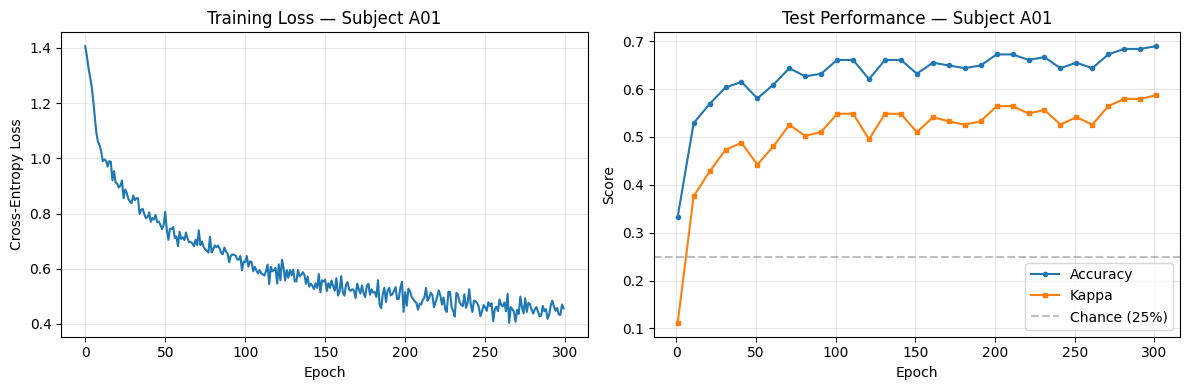

In [63]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(a01_metrics['train_losses'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss — Subject A01')
axes[0].grid(True, alpha=0.3)

eval_epochs = list(range(1, len(a01_metrics['test_accs'])*10 + 1, 10))
if len(eval_epochs) > len(a01_metrics['test_accs']):
    eval_epochs = eval_epochs[:len(a01_metrics['test_accs'])]
axes[1].plot(eval_epochs, a01_metrics['test_accs'], marker='o', markersize=3, label='Accuracy')
axes[1].plot(eval_epochs, a01_metrics['test_kappas'], marker='s', markersize=3, label='Kappa')
axes[1].axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Chance (25%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Test Performance — Subject A01')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

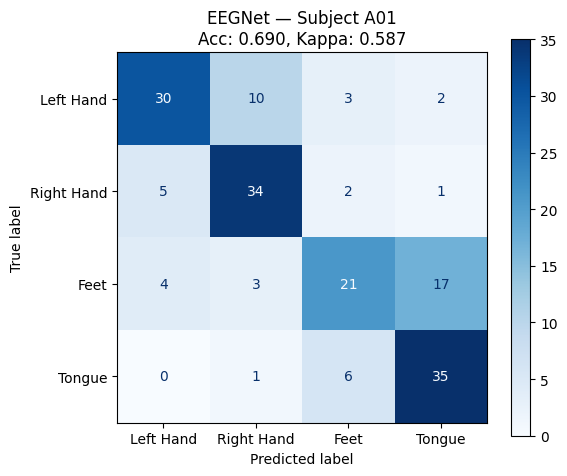

In [64]:
# Confusion matrix for A01
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
cm = confusion_matrix(a01_metrics['final_labels'], a01_metrics['final_preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f"EEGNet — Subject A01\nAcc: {a01_metrics['final_acc']:.3f}, Kappa: {a01_metrics['final_kappa']:.3f}")
plt.tight_layout()
plt.show()

### Decision — Single-subject results

1. Compare EEGNet's accuracy and kappa on A01 to your CSP+LDA and CSP+SVM results from Notebook 4. Is EEGNet better, worse, or comparable? Given that EEGNet has ~2,000 parameters learning from ~288 trials, does the result surprise you?

2. Look at the confusion matrix. Are the same class pairs confused as in your CSP results? If so, what does this tell you about whether the difficulty is in the *model* or in the *signal*?

3. The training loss keeps decreasing over 300 epochs. Does the test accuracy keep improving at the same rate, or does it plateau? What does this suggest about overfitting, and how is dropout helping?

*Write your answers here.*

---

## Part 8 — Full 9-Subject Evaluation

### Why all 9 subjects matter

Single-subject results are not publishable or comparable to the literature. BCI performance varies dramatically between subjects — some people produce strong, separable motor imagery signals ("BCI literate"), while others produce weak or noisy signals ("BCI illiterate"). The mean ± std across all 9 subjects captures both the average capability and the variability.

> **Why this matters for deployed BCI:** If you're building a BCI product, you can't just report results on the best 3 subjects. You need to know how your system performs on the worst-case user. The std tells you how robust your method is across the population.

### Task — Run EEGNet on all 9 subjects

The loop below trains a fresh EEGNet for each subject (subject-dependent evaluation). Each subject gets its own model — no transfer across subjects.

In [65]:
METRICS_PATH_ALL = 'metrics/eegnet_all_subjects.pt'

if os.path.exists(METRICS_PATH_ALL):
    all_results = torch.load(METRICS_PATH_ALL,weights_only=False)
    print("Loaded cached 9-subject results.")
    for subj in sorted(all_results.keys()):
        r = all_results[subj]
        print(f"  {subj}: acc={r['accuracy']:.4f}, kappa={r['kappa']:.4f}")
else:
    all_results = {}
    subjects = [f'A0{i}' for i in range(1, 10)]
    
    for subj in subjects:
        print(f"\n{'='*50}")
        print(f"Training Subject {subj}")
        print(f"{'='*50}")
        
        # Load data
        data = run_pipeline(subj, DATA_DIR)
        X_tr = data['X_train']
        X_te = data['X_test']
        y_tr = data['y_train']
        y_te = data['y_test']
        
        # Create loaders
        tr_loader = DataLoader(EEGDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                               shuffle=True, drop_last=False)
        te_loader = DataLoader(EEGDataset(X_te, y_te), batch_size=BATCH_SIZE,
                               shuffle=False, drop_last=False)
        
        # Train
        model = EEGNet().to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        
        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, tr_loader, optimizer, DEVICE)
            if (epoch + 1) % 100 == 0:
                acc, kappa, _, _ = evaluate(model, te_loader, DEVICE)
                print(f"  Epoch {epoch+1}/{N_EPOCHS} | loss: {loss:.4f} | acc: {acc:.4f} | kappa: {kappa:.4f}")
        
        # Final evaluation
        acc, kappa, preds, labels = evaluate(model, te_loader, DEVICE)
        all_results[subj] = {
            'accuracy': acc,
            'kappa': kappa,
            'preds': preds,
            'labels': labels
        }
        print(f"  Final: acc={acc:.4f}, kappa={kappa:.4f}")
        
        # Save model weights per subject
        os.makedirs('models', exist_ok=True)
        torch.save(model.state_dict(), f'models/eegnet_{subj}.pt')
    
    # Save all results
    os.makedirs('metrics', exist_ok=True)
    torch.save(all_results, METRICS_PATH_ALL)
    print("\nAll results saved.")

Loaded cached 9-subject results.
  A01: acc=0.6552, kappa=0.5416
  A02: acc=0.4540, kappa=0.2718
  A03: acc=0.7126, kappa=0.6175
  A04: acc=0.3793, kappa=0.1713
  A05: acc=0.3678, kappa=0.1585
  A06: acc=0.4828, kappa=0.3101
  A07: acc=0.6839, kappa=0.5782
  A08: acc=0.6322, kappa=0.5109
  A09: acc=0.7069, kappa=0.6087


In [66]:
# Summary statistics
accs   = [all_results[s]['accuracy'] for s in sorted(all_results.keys())]
kappas = [all_results[s]['kappa']    for s in sorted(all_results.keys())]

print(f"{'Subject':<10} {'Accuracy':>10} {'Kappa':>10}")
print('-' * 32)
for subj in sorted(all_results.keys()):
    r = all_results[subj]
    print(f"{subj:<10} {r['accuracy']:>10.4f} {r['kappa']:>10.4f}")
print('-' * 32)
print(f"{'Mean':<10} {np.mean(accs):>10.4f} {np.mean(kappas):>10.4f}")
print(f"{'Std':<10} {np.std(accs):>10.4f} {np.std(kappas):>10.4f}")
print(f"\nAccuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Kappa    : {np.mean(kappas):.3f} ± {np.std(kappas):.3f}")

Subject      Accuracy      Kappa
--------------------------------
A01            0.6552     0.5416
A02            0.4540     0.2718
A03            0.7126     0.6175
A04            0.3793     0.1713
A05            0.3678     0.1585
A06            0.4828     0.3101
A07            0.6839     0.5782
A08            0.6322     0.5109
A09            0.7069     0.6087
--------------------------------
Mean           0.5639     0.4187
Std            0.1338     0.1785

Accuracy : 0.564 ± 0.134
Kappa    : 0.419 ± 0.179


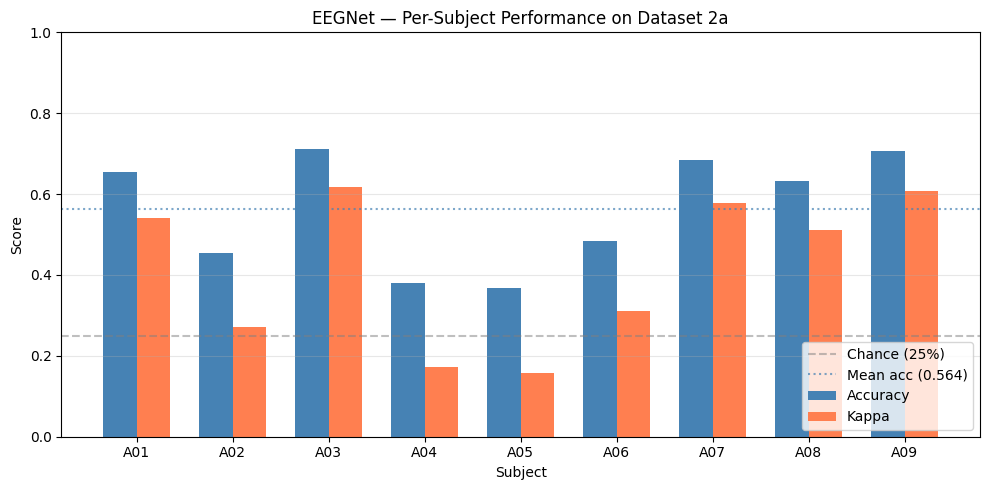

In [67]:
# Per-subject bar chart
subjects = sorted(all_results.keys())
accs_plot   = [all_results[s]['accuracy'] for s in subjects]
kappas_plot = [all_results[s]['kappa']    for s in subjects]

x = np.arange(len(subjects))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs_plot,   width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, kappas_plot, width, label='Kappa',    color='coral')

ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Chance (25%)')
ax.axhline(y=np.mean(accs_plot), color='steelblue', linestyle=':', alpha=0.7, label=f'Mean acc ({np.mean(accs_plot):.3f})')

ax.set_xlabel('Subject')
ax.set_ylabel('Score')
ax.set_title('EEGNet — Per-Subject Performance on Dataset 2a')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Decision — Cross-subject variability

1. Which subject has the highest accuracy? Which has the lowest? The gap between best and worst is ___ percentage points. In a deployed BCI product, what would you do about the worst-performing user?

2. Compare EEGNet's mean accuracy and kappa across all 9 subjects to your CSP+LDA/SVM results from Notebook 4. Fill in:
   - CSP+LDA: accuracy = ___ ± ___, kappa = ___ ± ___
   - CSP+SVM: accuracy = ___ ± ___, kappa = ___ ± ___
   - EEGNet:  accuracy = ___ ± ___, kappa = ___ ± ___
   
   The std of EEGNet is ___ (higher/lower/similar) to CSP+LDA. This means EEGNet is ___ (more/less/equally) robust across subjects.

3. Are the subjects that are hard for CSP also hard for EEGNet? If so, this suggests the difficulty is ___ (model-dependent / signal-dependent). What does this imply about whether a better model alone can solve the "BCI illiteracy" problem?

*Write your answers here.*

---

## Part 9 — Ablation Experiments

Now that you have a working baseline, let's understand which design choices matter.

### Ablation 1: Depth multiplier D

The depth multiplier $D$ controls how many spatial filters EEGNet learns per temporal filter. The default is $D = 2$ (so 16 spatial features total with $F_1 = 8$).

**Hypothesis:** Write your prediction below before running the experiment.

> I predict that increasing D from 2 to 4 will ___ (improve / hurt / not change) accuracy because ___. I predict D=1 will ___ because ___.

In [68]:
# Ablation 1: Depth multiplier D
# We run on Subject A01 only for speed

ABLATION_D_PATH = 'metrics/ablation_depth_multiplier.pt'

if os.path.exists(ABLATION_D_PATH):
    ablation_d_results = torch.load(ABLATION_D_PATH,weights_only=False)
    print("Loaded cached ablation results.")
else:
    d_values = [1, 2, 4]
    ablation_d_results = {}
    
    for d_val in d_values:
        print(f"\nD={d_val}:")
        model = EEGNet(D=d_val).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        n_params = sum(p.numel() for p in model.parameters())
        
        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        
        acc, kappa, _, _ = evaluate(model, test_loader, DEVICE)
        ablation_d_results[d_val] = {'accuracy': acc, 'kappa': kappa, 'n_params': n_params}
        print(f"  D={d_val}: acc={acc:.4f}, kappa={kappa:.4f}, params={n_params:,}")
    
    os.makedirs('metrics', exist_ok=True)
    torch.save(ablation_d_results, ABLATION_D_PATH)

print(f"\n{'D':>5} {'Accuracy':>10} {'Kappa':>10} {'Params':>10}")
print('-' * 38)
for d_val in sorted(ablation_d_results.keys()):
    r = ablation_d_results[d_val]
    print(f"{d_val:>5} {r['accuracy']:>10.4f} {r['kappa']:>10.4f} {r['n_params']:>10,}")

Loaded cached ablation results.

    D   Accuracy      Kappa     Params
--------------------------------------
    1     0.6149     0.4876      1,644
    2     0.7069     0.6099      2,396
    4     0.6322     0.5104      4,284


**Observation — Depth multiplier:**

> D=1 achieved ___% accuracy with ___ parameters. D=2 achieved ___% with ___ parameters. D=4 achieved ___% with ___ parameters.
>
> The relationship between D and accuracy is ___. Increasing D (increases / does not increase / hurts) accuracy despite (more / fewer) parameters. This is consistent with the general principle that on small datasets (288 trials), ___ because ___.
>
> For a deployed BCI product where inference speed matters, D=___ is the best tradeoff because ___.

### Ablation 2: Dropout rate

Dropout is the primary regularizer in EEGNet. With only ~288 training trials, overfitting is a real concern.

**Hypothesis:**
> I predict that dropout=0.25 will ___ compared to dropout=0.5 because ___. I predict dropout=0.75 will ___ because ___.

In [69]:
# Ablation 2: Dropout rate

ABLATION_DROP_PATH = 'metrics/ablation_dropout.pt'

if os.path.exists(ABLATION_DROP_PATH):
    ablation_drop_results = torch.load(ABLATION_DROP_PATH,weights_only=False)
    print("Loaded cached dropout ablation results.")
else:
    drop_values = [0.25, 0.5, 0.75]
    ablation_drop_results = {}
    
    for drop_val in drop_values:
        print(f"\nDropout={drop_val}:")
        model = EEGNet(dropout=drop_val).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        
        train_losses = []
        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
            train_losses.append(loss)
        
        acc, kappa, _, _ = evaluate(model, test_loader, DEVICE)
        ablation_drop_results[drop_val] = {
            'accuracy': acc, 'kappa': kappa,
            'final_train_loss': train_losses[-1]
        }
        print(f"  Dropout={drop_val}: acc={acc:.4f}, kappa={kappa:.4f}, final_loss={train_losses[-1]:.4f}")
    
    os.makedirs('metrics', exist_ok=True)
    torch.save(ablation_drop_results, ABLATION_DROP_PATH)

print(f"\n{'Dropout':>10} {'Accuracy':>10} {'Kappa':>10} {'Final Loss':>12}")
print('-' * 45)
for drop_val in sorted(ablation_drop_results.keys()):
    r = ablation_drop_results[drop_val]
    print(f"{drop_val:>10.2f} {r['accuracy']:>10.4f} {r['kappa']:>10.4f} {r['final_train_loss']:>12.4f}")

Loaded cached dropout ablation results.

   Dropout   Accuracy      Kappa   Final Loss
---------------------------------------------
      0.25     0.6494     0.5328       0.2412
      0.50     0.6552     0.5411       0.4414
      0.75     0.5632     0.4189       0.8337


**Observation — Dropout:**

> With dropout=0.25, the final training loss was ___ and test accuracy was ___%. With dropout=0.5, loss=___ and acc=___%. With dropout=0.75, loss=___ and acc=___%.
>
> Lower dropout (0.25) leads to (lower / higher) training loss but (lower / higher) test accuracy. This is a textbook example of ___ (underfitting / overfitting). The gap between training loss and test accuracy is ___ (larger / smaller) with low dropout.
>
> For EEG datasets with ~288 trials per subject, dropout=___ provides the best bias-variance tradeoff.

### Ablation 3: Temporal kernel length

The temporal kernel length determines what frequency content EEGNet can capture. `kern_len = fs // 2 = 125` is the default.

Recall from the signal processing notebook: a filter of length $L$ at sampling rate $f_s$ has a minimum resolvable frequency of approximately $f_{min} \approx f_s / L$.

| kern_len | f_min (approx) | Frequency bands covered |
|---|---|---|
| 32 | ~8 Hz | Alpha, beta, gamma only |
| 64 | ~4 Hz | Theta and above |
| 125 | ~2 Hz | Delta and above (full range) |

**Hypothesis:**
> I predict that kern_len=32 will ___ because it misses ___. I predict kern_len=64 will ___ relative to 125 because ___.

In [70]:
# Ablation 3: Temporal kernel length

ABLATION_KERN_PATH = 'metrics/ablation_kern_len.pt'

if os.path.exists(ABLATION_KERN_PATH):
    ablation_kern_results = torch.load(ABLATION_KERN_PATH,weights_only=False)
    print("Loaded cached kernel ablation results.")
else:
    kern_values = [32, 64, 125]
    ablation_kern_results = {}
    
    for kern_val in kern_values:
        print(f"\nkern_len={kern_val}:")
        model = EEGNet(kern_len=kern_val).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        n_params = sum(p.numel() for p in model.parameters())
        
        for epoch in range(N_EPOCHS):
            loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        
        acc, kappa, _, _ = evaluate(model, test_loader, DEVICE)
        ablation_kern_results[kern_val] = {'accuracy': acc, 'kappa': kappa, 'n_params': n_params}
        print(f"  kern_len={kern_val}: acc={acc:.4f}, kappa={kappa:.4f}, params={n_params:,}")
    
    os.makedirs('metrics', exist_ok=True)
    torch.save(ablation_kern_results, ABLATION_KERN_PATH)

print(f"\n{'kern_len':>10} {'Accuracy':>10} {'Kappa':>10} {'Params':>10}")
print('-' * 43)
for kern_val in sorted(ablation_kern_results.keys()):
    r = ablation_kern_results[kern_val]
    print(f"{kern_val:>10} {r['accuracy']:>10.4f} {r['kappa']:>10.4f} {r['n_params']:>10,}")

Loaded cached kernel ablation results.

  kern_len   Accuracy      Kappa     Params
-------------------------------------------
        32     0.6782     0.5717      1,652
        64     0.6954     0.5949      1,908
       125     0.6322     0.5111      2,396


**Observation — Temporal kernel length:**

> kern_len=32 achieved ___% accuracy. kern_len=64 achieved ___%. kern_len=125 achieved ___%.
>
> The pattern shows that ___ (longer / shorter) kernels are (better / worse / similar). This makes sense because motor imagery signals are primarily in the ___ Hz range, and a kernel of length ___ is sufficient to capture these frequencies.
>
> The parameter count difference between kern_len=32 and kern_len=125 is ___. For a deployed BCI where latency matters, kernel length ___ would be the best tradeoff because ___.

---

## Part 10 — What EEGNet Learned: Visualizing Temporal Filters

### Connecting back to signal processing

EEGNet's first layer learns temporal filters. If the architecture is working as intended, these learned filters should look like band-pass filters — isolating frequency bands relevant to motor imagery (mu: 8–13 Hz, beta: 13–30 Hz).

We can verify this by:
1. Extracting the temporal conv weights (shape: `(F1, 1, 1, kern_len)`)
2. Computing each filter's frequency response using FFT
3. Checking if the filters concentrate on EEG-relevant frequency bands

This is not a new concept — you know FFT from the signal processing notebook. The new insight is that the *network discovered these frequency filters from data*, rather than us specifying them by hand.

Temporal conv weight shape: (8, 1, 1, 125)


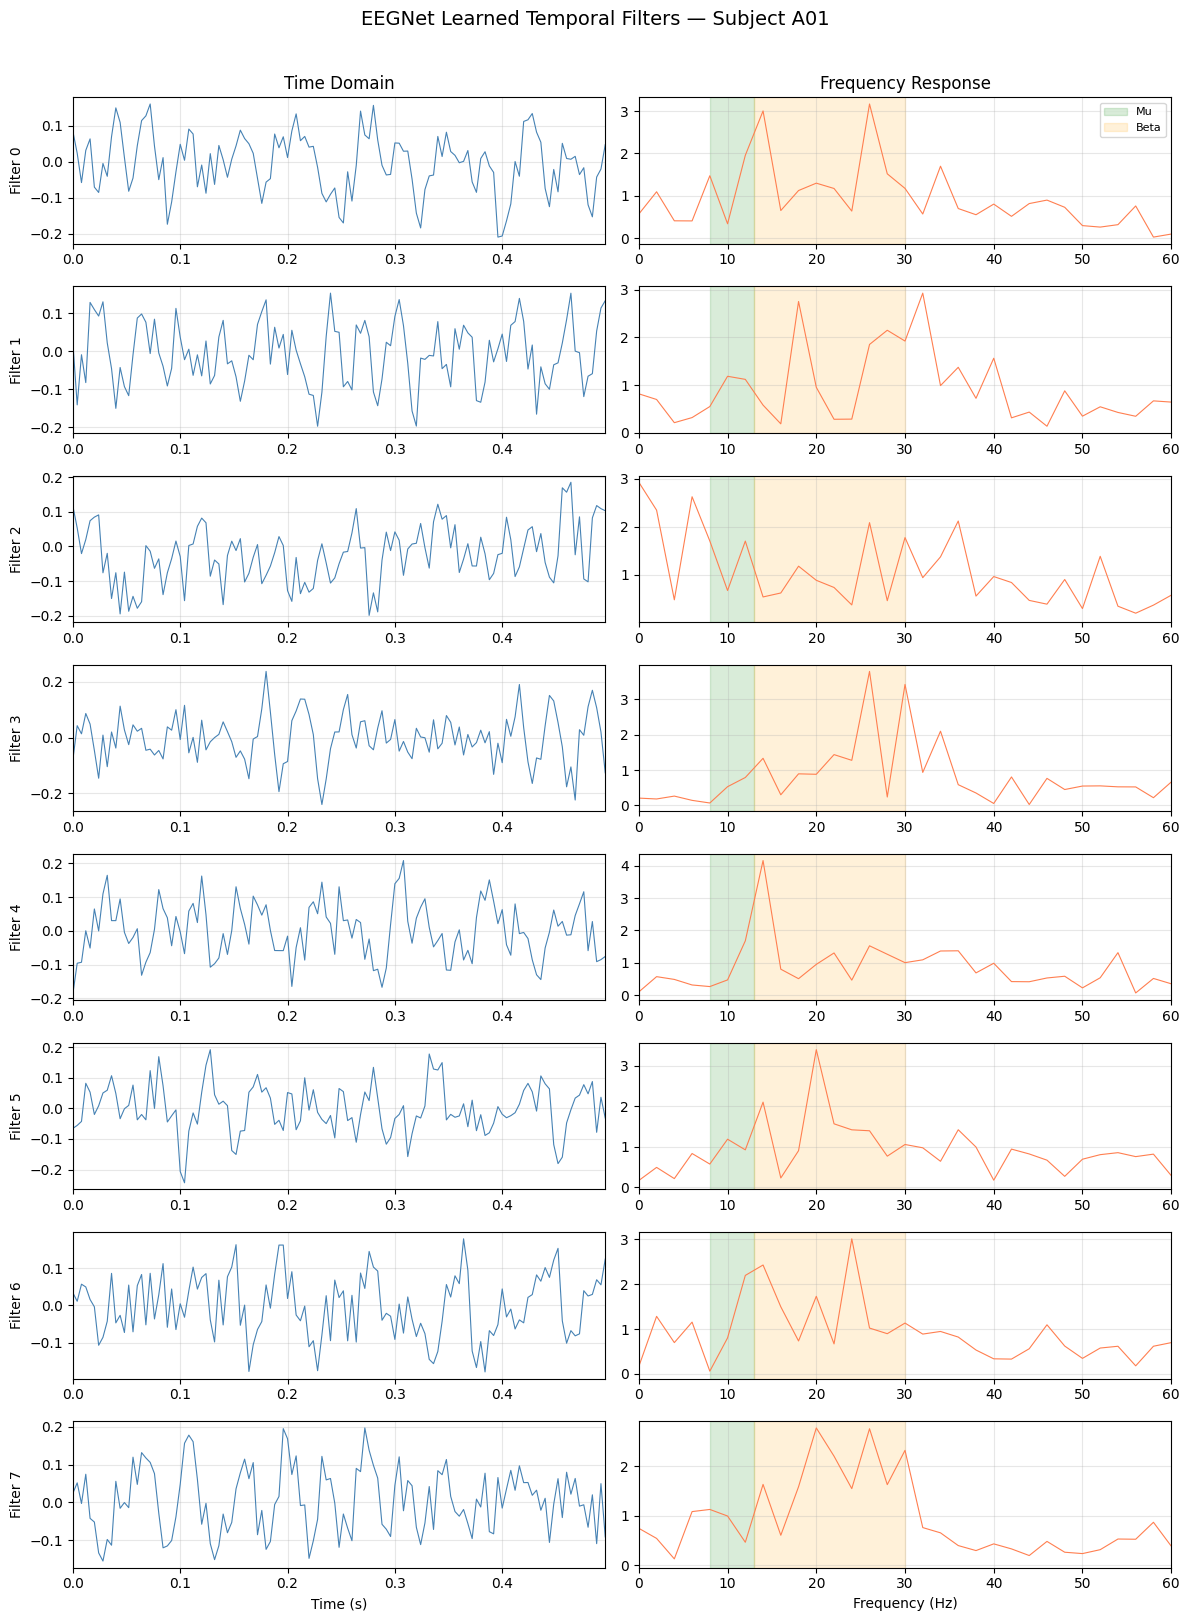

In [71]:
# Load the trained A01 model
model_viz = EEGNet().to(DEVICE)
model_viz.load_state_dict(torch.load(MODEL_PATH_A01, map_location=DEVICE))
model_viz.eval()

# Extract temporal conv weights
# Shape: (F1, 1, 1, kern_len) = (8, 1, 1, 125)
temporal_weights = model_viz.block1[0].weight.detach().cpu().numpy()
print(f"Temporal conv weight shape: {temporal_weights.shape}")

fs = 250  # Hz
F1 = temporal_weights.shape[0]

fig, axes = plt.subplots(F1, 2, figsize=(12, 2 * F1))

for i in range(F1):
    # Filter in time domain
    filt = temporal_weights[i, 0, 0, :]  # shape: (kern_len,)
    
    # Time domain
    t = np.arange(len(filt)) / fs
    axes[i, 0].plot(t, filt, color='steelblue', linewidth=0.8)
    axes[i, 0].set_ylabel(f'Filter {i}')
    axes[i, 0].set_xlim(0, t[-1])
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Time Domain')
    if i == F1 - 1:
        axes[i, 0].set_xlabel('Time (s)')
    
    # Frequency response
    freqs = np.fft.rfftfreq(len(filt), d=1/fs)
    fft_mag = np.abs(np.fft.rfft(filt))
    
    axes[i, 1].plot(freqs, fft_mag, color='coral', linewidth=0.8)
    axes[i, 1].axvspan(8, 13, alpha=0.15, color='green', label='Mu' if i == 0 else '')
    axes[i, 1].axvspan(13, 30, alpha=0.15, color='orange', label='Beta' if i == 0 else '')
    axes[i, 1].set_xlim(0, 60)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Frequency Response')
        axes[i, 1].legend(fontsize=8)
    if i == F1 - 1:
        axes[i, 1].set_xlabel('Frequency (Hz)')

plt.suptitle('EEGNet Learned Temporal Filters — Subject A01', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Decision — Learned filters

1. Do any of the 8 learned filters concentrate on the mu (8–13 Hz) or beta (13–30 Hz) bands? If so, this confirms that EEGNet "rediscovered" the frequency bands that are known to be relevant for motor imagery — without being told about them.

2. Are there filters that focus on frequencies above 30 Hz (gamma) or below 4 Hz (delta)? These bands are generally less relevant for motor imagery. If EEGNet learned filters for them, what might this mean? (Hint: consider noise, muscle artifacts, or the possibility that these bands carry some information the literature underestimates.)

3. Compare this to CSP: CSP required you to *first* band-pass filter the data (the preprocessing pipeline filtered to 4–38 Hz), *then* learn spatial filters. EEGNet learns its own frequency filters. Which approach is more flexible? Which is more data-efficient?

*Write your answers here.*

---

## Part 11 — Bridge to EEG Conformer

### What EEGNet can and cannot do

EEGNet's temporal filters have **fixed kernel size** — they operate on a local window of `kern_len` samples. This means:

- **Short-range patterns**: well captured (e.g., oscillatory bursts within 0.5 seconds)
- **Long-range dependencies**: poorly captured (e.g., temporal evolution of ERD over a 4-second trial)

The separable conv in Block 2 has kernel size 16 (64 ms at 250 Hz) — even shorter range. There's no mechanism for learning that "ERD at 0.5s predicts class X, but only if preceded by ERS at 0.2s."

### Preview: how Transformers help

Self-attention (which you know from GPT/ViT) computes relationships between *all pairs* of positions. Applied to EEG:
- Token at time $t_1$ can attend to token at time $t_{100}$ with the same computational cost as attending to $t_2$.
- This captures long-range temporal dependencies that fixed-kernel convolutions miss.

The **EEG Conformer** (Notebook 6) combines:
- EEGNet's CNN front-end (temporal + spatial filtering) as a patch encoder
- Transformer self-attention for long-range temporal modeling

| Feature | EEGNet | EEG Conformer |
|---|---|---|
| Temporal modeling | Fixed kernel (local) | Self-attention (global) |
| Parameters | ~2,000 | ~10,000+ |
| Needs more data? | No | Yes |
| When it wins | Short windows, small data | Longer windows, more data |

### Save your baseline

Your EEGNet results across 9 subjects are the **deep learning baseline** for the capstone (Notebook 7). In the capstone, you'll compare CSP+LDA, EEGNet, and EEG Conformer side by side.

In [72]:
# Save final summary for capstone comparison
summary = {
    'method': 'EEGNet',
    'per_subject': all_results,
    'mean_accuracy': float(np.mean(accs)),
    'std_accuracy': float(np.std(accs)),
    'mean_kappa': float(np.mean(kappas)),
    'std_kappa': float(np.std(kappas)),
    'hyperparams': {
        'F1': 8, 'D': 2, 'F2': 16,
        'kern_len': 125, 'sep_kern': 16,
        'pool1': 4, 'pool2': 8,
        'dropout': 0.5,
        'lr': LR, 'epochs': N_EPOCHS, 'batch_size': BATCH_SIZE
    }
}

torch.save(summary, 'metrics/eegnet_summary.pt')
print("EEGNet summary saved for capstone comparison.")
print(f"\nFinal results:")
print(f"  Accuracy: {summary['mean_accuracy']:.3f} ± {summary['std_accuracy']:.3f}")
print(f"  Kappa:    {summary['mean_kappa']:.3f} ± {summary['std_kappa']:.3f}")

EEGNet summary saved for capstone comparison.

Final results:
  Accuracy: 0.564 ± 0.134
  Kappa:    0.419 ± 0.179


---

## Summary

In this notebook you:

1. Learned **depthwise convolution** — a constrained conv where each filter sees only one input channel, used as a spatial filter over EEG channels (the neural network analog of CSP).
2. Learned **separable convolution** — depthwise + pointwise, which captures the same expressiveness as standard conv with far fewer parameters.
3. Implemented **EEGNet** from scratch — a 3-block architecture (temporal conv → depthwise spatial conv → separable conv → classifier) that replaces the entire CSP + LDA pipeline with an end-to-end learnable model.
4. Trained and evaluated on all 9 subjects with proper caching.
5. Ran ablation experiments on depth multiplier, dropout, and temporal kernel length.
6. Visualized learned temporal filters and verified they capture EEG-relevant frequency bands.

**Key takeaways:**
- EEGNet's architecture directly mirrors the EEG signal processing pipeline: frequency filtering → spatial filtering → feature extraction → classification.
- Despite being end-to-end learnable, EEGNet doesn't always beat CSP+LDA on small datasets — the closed-form CSP solution is hard to beat with only 288 training trials.
- The biggest performance bottleneck is often the *signal*, not the *model* — the same subjects that are hard for CSP tend to be hard for EEGNet.

**Next:** Notebook 6 (EEG Conformer) adds self-attention to capture long-range temporal dependencies that EEGNet's fixed kernels miss.